# Lab 9 — Evaluating RAG with LLM-as-Judge
### *Measure retrieval quality, answer quality, and faithfulness across RAG configurations.*

<a href="https://colab.research.google.com/github/tulane-intro-ai-engineering/main/blob/main/labs/trust_lab.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

---

## Overview
In this lab, you will build an evaluation harness for Retrieval-Augmented Generation (RAG) systems using an **LLM-as-judge**.

You will:
1) run multiple RAG configurations (different `k` and chunk sizes),
2) evaluate outputs with a judge prompt,
3) compute and compare three metrics,
4) edit the judge prompt and observe how scoring behavior changes.

---

## Metrics in this lab
- **Retrieval quality:** Did we retrieve evidence that is relevant to the question?
- **Answer quality:** Does the answer match the gold answer?
- **Faithfulness (assertion-level):** What fraction of answer assertions are supported by retrieved context assertions?

---

## Learning goals
- Build a small, repeatable RAG evaluation pipeline.
- Use LLM-as-judge prompts to score retrieval/answer/faithfulness.
- Improve evaluator reliability by editing judge instructions.
- Compare RAG specs and explain why metrics shift.


In [1]:
# @title 🔧 Setup (Run this first)
!git clone --depth 1 -q https://github.com/tulane-intro-ai-engineering/main.git
import sys; sys.path.append("/content/main")

import json
import re
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from course_utils import lab9_setup, get_text_embedding
lab9_setup()

import dspy
lm = dspy.LM("openai/gpt-4o-mini")
dspy.settings.configure(lm=lm)

np.random.seed(7)
print("✅ Environment ready for RAG evaluation lab!")


🔧 Setting up your environment...
  → Installing core packages...
installing mermaid-python
  → Installing additional packages: dspy
installing dspy
  → Setting random seed for reproducible results...
  → Checking API key...
🔑 Enter your OpenAI API key.
   (It will only be stored in this Colab runtime - it's safe!)
   Get your key from: https://platform.openai.com/api-keys
OpenAI API key: ··········
✅ API key set.
  → Adding course files to path...
✅ Setup complete!
✅ lab9_setup complete — ready.
✅ Environment ready for RAG evaluation lab!


## Pre-Lab Questions
Answer in 1-2 sentences each. (Edit this cell.)

1. Why can a high retrieval score still fail to produce a good final answer?
2. What is the difference between answer quality and faithfulness?
3. Why might two judge prompts produce different metric values on the same outputs?

Your answers:
1)
2)
3)


## Scientific Question & Hypothesis

**Question:**
How do RAG design choices (chunk size and number of retrieved chunks `k`) change:
- retrieval quality,
- answer quality,
- and faithfulness?

**My hypothesis:**
I expect increasing `k` from ___ to ___ will (improve / hurt) __________ because __________.
I expect chunk size (small / large) to perform better on __________ because __________.

Write your hypothesis here:


## Scientific Process Plan
- **Question:** How do RAG specs affect retrieval quality, answer quality, and faithfulness?
- **Hypothesis:** You wrote it above.
- **Experiment:** Run 3-4 RAG configs over the same evaluation set.
- **Measurement:** Score each QA pair with an LLM judge using explicit rubrics.
- **Conclusion:** Identify which config is best and whether judge prompt wording affects conclusions.


# Part 1 - Corpus + Evaluation Set (harder version)
You are given:
1. A document corpus with **confounders** (old vs current policies, similar numbers)
2. A QA evaluation set with factual, multi-hop, and unanswerable questions

This design makes retrieval and faithfulness less likely to be perfect.
In a real system, your eval set should come from real user questions and human-verified reference answers.


In [2]:
# @title Dataset (harder, with confounders)
corpus_docs = [
    {
        "doc_id": "remote_policy_current_2025",
        "title": "Remote Work Policy (Current, 2025)",
        "text": "Employees may work remotely up to three days per week with manager approval. Core collaboration hours are 10:00-15:00 local time. Security training is required annually.",
    },
    {
        "doc_id": "remote_policy_pilot_2023",
        "title": "Remote Work Pilot (Archived, 2023)",
        "text": "During the pilot period, employees could work remotely up to two days per week. Team leads could approve exceptions during the pilot only.",
    },
    {
        "doc_id": "expenses_policy_current_2025",
        "title": "Travel and Expense Policy (Current, 2025)",
        "text": "Meals are reimbursed up to 60 dollars per day with itemized receipts. Hotel reimbursement requires pre-approval for nightly rates above 180 dollars. Expense reports are due within 30 days.",
    },
    {
        "doc_id": "expenses_policy_old_2022",
        "title": "Travel and Expense Policy (Archived, 2022)",
        "text": "Meals were reimbursed up to 50 dollars per day. Expense reports were due within 45 days. This policy has been replaced.",
    },
    {
        "doc_id": "benefits_parental_leave",
        "title": "Benefits Handbook",
        "text": "Full-time employees receive 12 weeks of paid parental leave after six months of employment. Part-time employees receive 6 weeks of paid parental leave.",
    },
    {
        "doc_id": "benefits_faq",
        "title": "Benefits FAQ",
        "text": "Employees may request up to four additional weeks of unpaid leave after paid parental leave, subject to manager approval.",
    },
    {
        "doc_id": "it_password_policy",
        "title": "IT Security Guide",
        "text": "Passwords must be at least 14 characters and include letters, numbers, and symbols. Multi-factor authentication is mandatory for all company systems. Passwords expire every 180 days.",
    },
    {
        "doc_id": "product_sla_current",
        "title": "Customer Support SLA (Current)",
        "text": "Priority 1 incidents require a first response within one hour and updates every two hours. Priority 2 incidents require a first response within four hours.",
    },
    {
        "doc_id": "product_sla_old",
        "title": "Customer Support SLA (Archived)",
        "text": "Under the old SLA, Priority 1 incidents required a first response within two hours and updates every three hours.",
    },
    {
        "doc_id": "engineering_release",
        "title": "Release Process",
        "text": "Production releases occur Tuesdays and Thursdays. Code freeze starts at 09:00 UTC on release days. Rollback plans must be attached to every release ticket.",
    },
    {
        "doc_id": "engineering_release_exceptions",
        "title": "Release Exceptions",
        "text": "Emergency releases are allowed on Fridays only with director approval. A post-release incident review must be filed within 24 hours.",
    },
]

eval_set = [
    {
        "question": "Under the current policy, how many remote days are allowed each week?",
        "gold_answer": "Under the current policy, employees may work remotely up to three days per week.",
    },
    {
        "question": "What was the remote-work limit during the archived pilot policy?",
        "gold_answer": "During the archived pilot, the remote-work limit was two days per week.",
    },
    {
        "question": "What is the current meal reimbursement limit per day?",
        "gold_answer": "The current meal reimbursement limit is 60 dollars per day.",
    },
    {
        "question": "How many days do employees have to submit expense reports under the current policy?",
        "gold_answer": "Under the current policy, expense reports are due within 30 days.",
    },
    {
        "question": "By how much did the meal reimbursement limit increase from the archived policy to the current policy?",
        "gold_answer": "It increased by 10 dollars, from 50 to 60 dollars per day.",
    },
    {
        "question": "For Priority 1 incidents, what are the current first-response and update targets?",
        "gold_answer": "Current targets are first response within one hour and updates every two hours.",
    },
    {
        "question": "Can part-time employees receive 12 weeks of paid parental leave?",
        "gold_answer": "No. Part-time employees receive 6 weeks of paid parental leave.",
    },
    {
        "question": "Are emergency releases allowed on Fridays, and if so, under what approval requirement?",
        "gold_answer": "Yes. Emergency Friday releases are allowed only with director approval.",
    },
    {
        "question": "Why did the company choose Tuesday and Thursday as regular release days?",
        "gold_answer": "INSUFFICIENT_CONTEXT",
    },
    {
        "question": "What is the password expiration period for company systems?",
        "gold_answer": "Passwords expire every 180 days.",
    },
]

eval_df = pd.DataFrame(eval_set)
print(f"Corpus docs: {len(corpus_docs)}")
print(f"Eval questions: {len(eval_df)}")
eval_df


Corpus docs: 11
Eval questions: 10


,question,gold_answer
0,"Under the current policy, how many remote days...","Under the current policy, employees may work r..."
1,What was the remote-work limit during the arch...,"During the archived pilot, the remote-work lim..."
2,What is the current meal reimbursement limit p...,The current meal reimbursement limit is 60 dol...
3,How many days do employees have to submit expe...,"Under the current policy, expense reports are ..."
4,By how much did the meal reimbursement limit i...,"It increased by 10 dollars, from 50 to 60 doll..."
5,"For Priority 1 incidents, what are the current...",Current targets are first response within one ...
6,Can part-time employees receive 12 weeks of pa...,No. Part-time employees receive 6 weeks of pai...
7,"Are emergency releases allowed on Fridays, and...",Yes. Emergency Friday releases are allowed onl...
8,Why did the company choose Tuesday and Thursda...,INSUFFICIENT_CONTEXT
9,What is the password expiration period for com...,Passwords expire every 180 days.


## Optional Hard-Mode Extension Pack
Use this to stress-test retrieval and faithfulness.

This extension adds adversarial questions with:
- current vs archived ambiguity,
- multi-hop composition,
- unanswerable prompts that tempt hallucination,
- numeric/entity near-misses.

Set `USE_HARD_MODE_EXTENSION = True` in the next cell to append these items to `eval_df`.

In [3]:
# @title Hard-mode extension pack (optional)
USE_HARD_MODE_EXTENSION = True

hard_mode_eval_set = [
    {
        "question": "Under the current SLA, are Priority 1 incidents updated every three hours?",
        "gold_answer": "No. Under the current SLA, Priority 1 incidents are updated every two hours.",
    },
    {
        "question": "What are the current and archived first-response targets for Priority 1 incidents?",
        "gold_answer": "Current is one hour; archived was two hours.",
    },
    {
        "question": "If an employee takes paid parental leave and then requests additional unpaid leave, what is the maximum total leave described in the docs?",
        "gold_answer": "Up to 16 weeks total for full-time employees (12 paid + up to 4 unpaid).",
    },
    {
        "question": "Does the current remote-work policy allow two days per week without manager approval?",
        "gold_answer": "No. The current policy allows up to three days per week with manager approval.",
    },
    {
        "question": "How many days earlier is the current expense-report deadline compared with the archived policy?",
        "gold_answer": "The current deadline is 15 days earlier (30 vs 45 days).",
    },
    {
        "question": "Can emergency Friday releases happen without any additional process requirement?",
        "gold_answer": "No. They require director approval, and a post-release incident review must be filed within 24 hours.",
    },
    {
        "question": "What timezone was used to choose core collaboration hours in the remote policy?",
        "gold_answer": "INSUFFICIENT_CONTEXT",
    },
    {
        "question": "What team proposed the archived travel policy updates in 2022?",
        "gold_answer": "INSUFFICIENT_CONTEXT",
    },
]

if USE_HARD_MODE_EXTENSION:
    eval_df = pd.concat([eval_df, pd.DataFrame(hard_mode_eval_set)], ignore_index=True)

print(f"Hard-mode enabled: {USE_HARD_MODE_EXTENSION}")
print(f"Total eval questions: {len(eval_df)}")
eval_df.tail(8)

Hard-mode enabled: True
Total eval questions: 18


,question,gold_answer
10,"Under the current SLA, are Priority 1 incident...","No. Under the current SLA, Priority 1 incident..."
11,What are the current and archived first-respon...,Current is one hour; archived was two hours.
12,If an employee takes paid parental leave and t...,Up to 16 weeks total for full-time employees (...
13,Does the current remote-work policy allow two ...,No. The current policy allows up to three days...
14,How many days earlier is the current expense-r...,The current deadline is 15 days earlier (30 vs...
15,Can emergency Friday releases happen without a...,"No. They require director approval, and a post..."
16,What timezone was used to choose core collabor...,INSUFFICIENT_CONTEXT
17,What team proposed the archived travel policy ...,INSUFFICIENT_CONTEXT


# Part 2 - Build a Configurable RAG Retriever
We will compare multiple RAG specs by changing:
- `chunk_size` (words per chunk)
- `k` (number of retrieved chunks)

You can add more configs later.


In [4]:
# @title Retrieval utilities + experiment configs

# In-memory caches to avoid repeated embedding calls during notebook reruns.
EMBED_CACHE = {}
CHUNK_INDEX_CACHE = {}


def _embed_cached(text):
    if text in EMBED_CACHE:
        return EMBED_CACHE[text]
    emb = np.array(get_text_embedding(text), dtype=float)
    EMBED_CACHE[text] = emb
    return emb


def chunk_text(text, chunk_size=60, overlap=15):
    words = text.split()
    if chunk_size <= overlap:
        raise ValueError("chunk_size must be greater than overlap")

    chunks = []
    step = chunk_size - overlap
    for i in range(0, len(words), step):
        window = words[i : i + chunk_size]
        if not window:
            continue
        chunks.append(" ".join(window))
        if i + chunk_size >= len(words):
            break
    return chunks


def _docs_fingerprint(docs):
    # Basic hashable fingerprint so cache invalidates if corpus text changes.
    return tuple((d["doc_id"], d["title"], d["text"]) for d in docs)


def build_chunk_index(docs, chunk_size=60, overlap=15):
    cache_key = (_docs_fingerprint(docs), int(chunk_size), int(overlap))
    if cache_key in CHUNK_INDEX_CACHE:
        return CHUNK_INDEX_CACHE[cache_key].copy()

    rows = []
    for doc in docs:
        doc_chunks = chunk_text(doc["text"], chunk_size=chunk_size, overlap=overlap)
        for j, c in enumerate(doc_chunks):
            rows.append(
                {
                    "doc_id": doc["doc_id"],
                    "title": doc["title"],
                    "chunk_id": f"{doc['doc_id']}::c{j}",
                    "text": c,
                    "embedding": _embed_cached(c),
                }
            )

    out = pd.DataFrame(rows)
    CHUNK_INDEX_CACHE[cache_key] = out.copy()
    return out


def cosine_sim(a, b):
    denom = (np.linalg.norm(a) * np.linalg.norm(b))
    if denom == 0:
        return 0.0
    return float(np.dot(a, b) / denom)


def retrieve(question, chunk_df, k=3):
    q_emb = _embed_cached(question)
    scores = [cosine_sim(q_emb, emb) for emb in chunk_df["embedding"].tolist()]
    out = chunk_df.copy()
    out["score"] = scores
    return out.sort_values("score", ascending=False).head(k).reset_index(drop=True)


rag_configs = [
    {"name": "tiny_chunks_k1", "chunk_size": 10, "k": 1},
    {"name": "tiny_chunks_k3", "chunk_size": 10, "k": 3},
    {"name": "small_chunks_k2", "chunk_size": 12, "k": 2},
    {"name": "large_chunks_k4", "chunk_size": 80, "k": 4},
]

pd.DataFrame(rag_configs)


,name,chunk_size,k
0,tiny_chunks_k1,10,1
1,tiny_chunks_k3,10,3
2,small_chunks_k2,12,2
3,large_chunks_k4,80,4


# Part 3 - RAG Answering Function
The function below asks an LLM to answer using only retrieved context. This creates outputs that your judge will score.


In [5]:
# @title Generate RAG answers

class RAGAnswer(dspy.Signature):
    """Answer from provided context only."""
    question = dspy.InputField(desc="User question")
    context = dspy.InputField(desc="Retrieved context chunks")
    answer = dspy.OutputField(desc="Concise answer grounded in context")

answer_program = dspy.Predict(RAGAnswer)


def format_context(retrieved_df):
    blocks = []
    for _, r in retrieved_df.iterrows():
        blocks.append(f"[{r['chunk_id']}] {r['text']}")
    return "\n\n".join(blocks)


def generate_rag_answer(question, retrieved_df):
    context = format_context(retrieved_df)
    pred = answer_program(
        question=question,
        context=(
            "Use ONLY the context below. If context is insufficient, say 'INSUFFICIENT_CONTEXT'.\n\n"
            + context
        ),
    )
    return str(pred.answer).strip(), context


# Part 4 - LLM-as-Judge Prompts (EDIT THESE)
You will use:
- one prompt for retrieval + answer quality, and
- two prompts for assertion-level faithfulness (extract + support).

Your task:
1. Complete the `extract_assertions` method below.
2. Complete the `compute_faithfulness_fraction` below
3. Run once with defaults.
4. Edit prompt wording to make scoring stricter or clearer.
5. Re-run and compare metric shifts.

Tip: Small wording changes can significantly alter metric values.


In [36]:
# @title Judge implementation (typed DSPy outputs + assertion-level faithfulness)
JUDGE_PROMPT = """
You are an evaluator for a RAG system.
Given a question, gold answer, model answer, and retrieved context, evaluate with this rubric:
- retrieval_quality = True if retrieved context contains information clearly relevant to answering the question.
- answer_quality = True if model answer is correct and consistent with the gold answer.
Be conservative. If unsure, return False.
""".strip()


class JudgeSignature(dspy.Signature):
    judge_prompt = dspy.InputField()
    question = dspy.InputField()
    gold_answer = dspy.InputField()
    model_answer = dspy.InputField()
    retrieved_context = dspy.InputField()

    retrieval_quality: bool = dspy.OutputField()
    answer_quality: bool = dspy.OutputField()
    rationale: str = dspy.OutputField()


class AssertionExtractionSignature(dspy.Signature):
    """Extract atomic factual assertions from text."""
    extraction_prompt = dspy.InputField()
    source_label = dspy.InputField(desc="Either ANSWER or CONTEXT")
    text = dspy.InputField(desc="Text to extract claims from")

    assertions: list[str] = dspy.OutputField(desc="List of atomic factual assertions")


class AssertionSupportSignature(dspy.Signature):
    """Decide whether one answer assertion is supported by context assertions."""
    support_prompt = dspy.InputField()
    answer_assertion = dspy.InputField()
    context_assertions = dspy.InputField(desc="List of context assertions")

    supported: bool = dspy.OutputField()
    reason: str = dspy.OutputField()


judge_program = dspy.Predict(JudgeSignature)
extract_assertions_program = dspy.Predict(AssertionExtractionSignature)
assertion_support_program = dspy.Predict(AssertionSupportSignature)


ASSERTION_EXTRACTION_PROMPT = (
    "Extract only atomic factual claims. "
    "Do not include opinions, instructions, or speculative statements."
)

ASSERTION_SUPPORT_PROMPT = (
    "Determine if the answer assertion is directly supported by one or more context assertions. "
    "Support requires semantic equivalence or clear entailment. "
    "If uncertain, mark unsupported."
)



def extract_assertions(source_label, text, extraction_prompt):
    ## TODO: Use the extract_assertions_program to extract and return the list of assertions for this text.
    return


def compute_faithfulness_fraction(answer_text, context_text, extraction_prompt, support_prompt):
    answer_assertions = extract_assertions("ANSWER", answer_text, extraction_prompt)
    context_assertions = extract_assertions("CONTEXT", context_text, extraction_prompt)

    if len(answer_assertions) == 0:
        return {
            "faithfulness": 1.0,
            "supported_count": 0,
            "answer_assertion_count": 0,
            "answer_assertions": [],
            "context_assertions": context_assertions,
            "support_details": [],
        }

    support_details = []
    supported_count = 0

    for ans_claim in answer_assertions:
        pred = # ... TODO Complete the call to assertion_support_program

        supported = bool(pred.supported)
        if supported:
            supported_count += 1

        support_details.append(
            {
                "answer_assertion": ans_claim,
                "supported": bool(supported),
                "reason": str(pred.reason).strip(),
            }
        )

    faithfulness = # ... TODO: Calculate faithfulness (fraction of assertions in the answer that are supported by the context)
    return {
        "faithfulness": float(faithfulness),
        "supported_count": int(supported_count),
        "answer_assertion_count": int(len(answer_assertions)),
        "answer_assertions": answer_assertions,
        "context_assertions": context_assertions,
        "support_details": support_details,
    }


def judge_example(question, gold_answer, model_answer, retrieved_context,
                  judge_prompt=JUDGE_PROMPT, extraction_prompt=ASSERTION_EXTRACTION_PROMPT,
                  support_prompt=ASSERTION_SUPPORT_PROMPT):
    pred = judge_program(
        judge_prompt=judge_prompt,
        question=question,
        gold_answer=gold_answer,
        model_answer=model_answer,
        retrieved_context=retrieved_context,
    )

    faith = compute_faithfulness_fraction(model_answer, retrieved_context, extraction_prompt, support_prompt)

    return {
        "retrieval_quality": bool(pred.retrieval_quality),
        "answer_quality": bool(pred.answer_quality),
        "faithfulness": float(faith["faithfulness"]),
        "supported_count": int(faith["supported_count"]),
        "answer_assertion_count": int(faith["answer_assertion_count"]),
        "answer_assertions": faith["answer_assertions"],
        "context_assertions": faith["context_assertions"],
        "support_details": faith["support_details"],
        "rationale": str(pred.rationale).strip(),
    }


In [37]:
# @title Run experiment: compare RAG specs
# To reduce cost/time during development, set MAX_QUESTIONS to a smaller number.
MAX_QUESTIONS = len(eval_df)

def run_rag_experiment(eval_df, corpus_docs, rag_configs, max_questions=None):
    if max_questions is None:
        max_questions = len(eval_df)

    rows = []
    subset = eval_df.head(max_questions).copy()

    for cfg in rag_configs:
        chunk_df = build_chunk_index(
            corpus_docs,
            chunk_size=cfg["chunk_size"],
            overlap=max(5, cfg["chunk_size"] // 4),
        )

        for _, ex in subset.iterrows():
            retrieved = retrieve(ex["question"], chunk_df, k=cfg["k"])
            answer, context = generate_rag_answer(ex["question"], retrieved)
            judge = judge_example(ex["question"], ex["gold_answer"], answer, context)

            rows.append(
                {
                    "config": cfg["name"],
                    "chunk_size": cfg["chunk_size"],
                    "k": cfg["k"],
                    "question": ex["question"],
                    "gold_answer": ex["gold_answer"],
                    "model_answer": answer,
                    "retrieved_context": context,
                    "retrieval_quality": judge["retrieval_quality"],
                    "answer_quality": judge["answer_quality"],
                    "faithfulness": judge["faithfulness"],
                    "supported_count": judge["supported_count"],
                    "answer_assertion_count": judge["answer_assertion_count"],
                    "answer_assertions": judge["answer_assertions"],
                    "context_assertions": judge["context_assertions"],
                    "support_details": judge["support_details"],
                    "judge_rationale": judge["rationale"],
                }
            )

    return pd.DataFrame(rows)


results_df = run_rag_experiment(eval_df, corpus_docs, rag_configs, max_questions=MAX_QUESTIONS)
results_df.head()


,config,chunk_size,k,question,gold_answer,model_answer,retrieved_context,retrieval_quality,answer_quality,faithfulness,supported_count,answer_assertion_count,answer_assertions,context_assertions,support_details,judge_rationale
0,tiny_chunks_k1,10,1,"Under the current policy, how many remote days...","Under the current policy, employees may work r...",Employees may work remotely up to three days p...,[remote_policy_current_2025::c0] Employees may...,True,True,1.0,1,1,[Employees may work remotely up to three days ...,[Employees may work remotely up to three days ...,[{'answer_assertion': 'Employees may work remo...,The retrieved context provides clear informati...
1,tiny_chunks_k1,10,1,What was the remote-work limit during the arch...,"During the archived pilot, the remote-work lim...",INSUFFICIENT_CONTEXT,[remote_policy_pilot_2023::c0] During the pilo...,True,True,1.0,0,0,[],[],[],The retrieved context indicates that the remot...
2,tiny_chunks_k1,10,1,What is the current meal reimbursement limit p...,The current meal reimbursement limit is 60 dol...,Meals are reimbursed up to 60 dollars per day.,[expenses_policy_current_2025::c0] Meals are r...,True,True,1.0,1,1,[Meals are reimbursed up to 60 dollars per day.],[Meals are reimbursed up to 60 dollars per day],[{'answer_assertion': 'Meals are reimbursed up...,The retrieved context provides clear informati...
3,tiny_chunks_k1,10,1,How many days do employees have to submit expe...,"Under the current policy, expense reports are ...",Employees have 30 days to submit expense repor...,[expenses_policy_current_2025::c4] 180 dollars...,True,True,1.0,1,1,[Employees have 30 days to submit expense repo...,"[180 dollars, Expense reports are due within 3...",[{'answer_assertion': 'Employees have 30 days ...,The retrieved context includes relevant inform...
4,tiny_chunks_k1,10,1,By how much did the meal reimbursement limit i...,"It increased by 10 dollars, from 50 to 60 doll...",INSUFFICIENT_CONTEXT,[expenses_policy_old_2022::c0] Meals were reim...,False,True,1.0,0,0,[],[Meals were reimbursed up to 50 dollars per day.],[],The retrieved context only mentions the old me...


In [38]:
# @title Aggregate metrics + inspect examples
metric_cols = ["retrieval_quality", "answer_quality", "faithfulness"]

metrics_by_config = (
    results_df.groupby(["config", "chunk_size", "k"], as_index=False)[metric_cols]
    .mean()
    .sort_values("faithfulness", ascending=False)
)

print("Average metrics by config:")
display(metrics_by_config)


Average metrics by config:


,config,chunk_size,k,retrieval_quality,answer_quality,faithfulness
2,tiny_chunks_k1,10,1,0.777778,0.777778,0.944444
1,small_chunks_k2,12,2,0.944444,0.722222,0.925926
0,large_chunks_k4,80,4,0.944444,0.944444,0.888889
3,tiny_chunks_k3,10,3,0.944444,0.833333,0.888889


In [39]:
print("\nSample rows (for error analysis):")
display(
    results_df[
        [
            "config",
            "question",
            "model_answer",
            "gold_answer",
            "retrieval_quality",
            "answer_quality",
            "faithfulness",
            "retrieved_context",
            "supported_count",
            "answer_assertion_count",
            "answer_assertions",
            "context_assertions",
            "judge_rationale",
        ]
    ].head(50)
)


Sample rows (for error analysis):


,config,question,model_answer,gold_answer,retrieval_quality,answer_quality,faithfulness,retrieved_context,supported_count,answer_assertion_count,answer_assertions,context_assertions,judge_rationale
0,tiny_chunks_k1,"Under the current policy, how many remote days...",Employees may work remotely up to three days p...,"Under the current policy, employees may work r...",True,True,1.000000,[remote_policy_current_2025::c0] Employees may...,1,1,[Employees may work remotely up to three days ...,[Employees may work remotely up to three days ...,The retrieved context provides clear informati...
1,tiny_chunks_k1,What was the remote-work limit during the arch...,INSUFFICIENT_CONTEXT,"During the archived pilot, the remote-work lim...",True,True,1.000000,[remote_policy_pilot_2023::c0] During the pilo...,0,0,[],[],The retrieved context indicates that the remot...
2,tiny_chunks_k1,What is the current meal reimbursement limit p...,Meals are reimbursed up to 60 dollars per day.,The current meal reimbursement limit is 60 dol...,True,True,1.000000,[expenses_policy_current_2025::c0] Meals are r...,1,1,[Meals are reimbursed up to 60 dollars per day.],[Meals are reimbursed up to 60 dollars per day],The retrieved context provides clear informati...
3,tiny_chunks_k1,How many days do employees have to submit expe...,Employees have 30 days to submit expense repor...,"Under the current policy, expense reports are ...",True,True,1.000000,[expenses_policy_current_2025::c4] 180 dollars...,1,1,[Employees have 30 days to submit expense repo...,"[180 dollars, Expense reports are due within 3...",The retrieved context includes relevant inform...
4,tiny_chunks_k1,By how much did the meal reimbursement limit i...,INSUFFICIENT_CONTEXT,"It increased by 10 dollars, from 50 to 60 doll...",False,True,1.000000,[expenses_policy_old_2022::c0] Meals were reim...,0,0,[],[Meals were reimbursed up to 50 dollars per day.],The retrieved context only mentions the old me...
5,tiny_chunks_k1,"For Priority 1 incidents, what are the current...",Priority 1 incidents require a first response ...,Current targets are first response within one ...,True,False,1.000000,[product_sla_current::c0] Priority 1 incidents...,1,1,[Priority 1 incidents require a first response...,[Priority 1 incidents require a first response...,The retrieved context contains relevant inform...
6,tiny_chunks_k1,Can part-time employees receive 12 weeks of pa...,INSUFFICIENT_CONTEXT,No. Part-time employees receive 6 weeks of pai...,False,True,1.000000,[benefits_parental_leave::c0] Full-time employ...,0,0,[],[Full-time employees receive 12 weeks of paid ...,The retrieved context only discusses benefits ...
7,tiny_chunks_k1,"Are emergency releases allowed on Fridays, and...",Emergency releases are allowed on Fridays only...,Yes. Emergency Friday releases are allowed onl...,True,True,1.000000,[engineering_release_exceptions::c0] Emergency...,1,1,[Emergency releases are allowed on Fridays onl...,[Emergency releases are allowed on Fridays onl...,The retrieved context contains information tha...
8,tiny_chunks_k1,Why did the company choose Tuesday and Thursda...,INSUFFICIENT_CONTEXT,INSUFFICIENT_CONTEXT,True,True,1.000000,[engineering_release::c0] Production releases ...,0,0,[],[Production releases occur Tuesdays and Thursd...,The retrieved context provides relevant inform...
9,tiny_chunks_k1,What is the password expiration period for com...,Passwords expire every 180 days for all compan...,Passwords expire every 180 days.,True,True,1.000000,[it_password_policy::c3] is mandatory for all ...,1,1,[Passwords expire every 180 days for all compa...,[it_password_policy::c3 is mandatory for all c...,The retrieved context contains relevant inform...


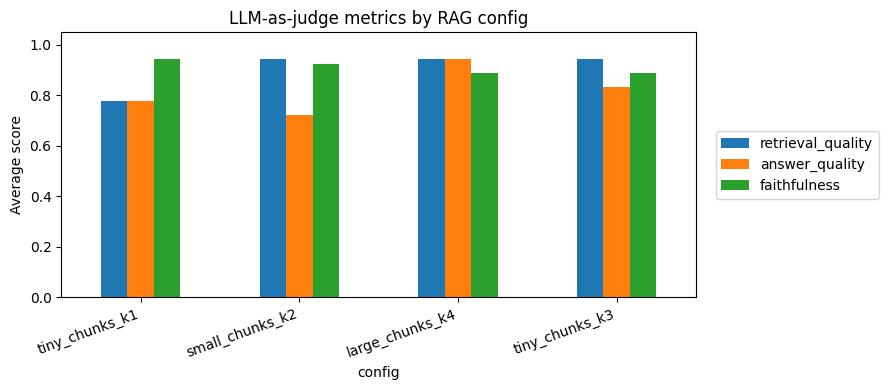

In [40]:
# @title Visualize metric differences
plot_df = metrics_by_config.copy()
plot_df = plot_df.set_index("config")

ax = plot_df[["retrieval_quality", "answer_quality", "faithfulness"]].plot(
    kind="bar", figsize=(9, 4)
)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Average score")
ax.set_title("LLM-as-judge metrics by RAG config")
plt.xticks(rotation=20, ha="right")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()


# Part 5 - Prompt Editing Challenge (required)
Now improve the evaluator itself.

### Task
1. Edit prompts passed into the `judge_example` method below
   - `judge_prompt` (retrieval quality + answer quality),
   - `extraction_prompt` (what counts as an assertion),
   - `support_prompt` (what counts as support).
   - (You can see their current values in the variables above: `JUDGE_PROMPT`, `ASSERTION_EXTRACTION_PROMPT`, `ASSERTION_SUPPORT_PROMPT`)
2. Re-run the judge on existing model outputs (cell below).
3. Compare old vs new metrics and explain **why** they changed.

Suggested edits:
- Require explicit mention of key facts for answer correctness.
- Treat numeric/date/entity claims as separate assertions.
- Make support stricter: require direct entailment, not topical overlap.
- Penalize answers that mix archived and current policies unless the question asks for comparison.


In [41]:
# @title Re-score with your edited judge prompt
baseline_metrics = metrics_by_config.copy()


def rescore_with_current_judge(results_df):
    rescored = []
    for _, r in results_df.iterrows():
        j = judge_example(
            judge_prompt="REPLACE ME", # TODO
            extraction_prompt="REPLACE ME", # TODO
            support_prompt="REPLACE ME", # TODO
            question=r["question"],
            gold_answer=r["gold_answer"],
            model_answer=r["model_answer"],
            retrieved_context=r["retrieved_context"],
        )
        rescored.append(
            {
                "retrieval_quality": j["retrieval_quality"],
                "answer_quality": j["answer_quality"],
                "faithfulness": j["faithfulness"],
                "supported_count": j["supported_count"],
                "answer_assertion_count": j["answer_assertion_count"],
                "support_details_new": j["support_details"],
                "judge_rationale_new": j["rationale"],
            }
        )

    out = results_df.copy()
    rescored_df = pd.DataFrame(rescored)
    for col in rescored_df.columns:
        out[col] = rescored_df[col]
    return out


rescored_df = rescore_with_current_judge(results_df)

edited_metrics = (
    rescored_df.groupby(["config", "chunk_size", "k"], as_index=False)[metric_cols]
    .mean()
    .sort_values("faithfulness", ascending=False)
)

comparison = baseline_metrics.merge(
    edited_metrics,
    on=["config", "chunk_size", "k"],
    suffixes=("_baseline", "_edited"),
)
for m in metric_cols:
    comparison[f"delta_{m}"] = comparison[f"{m}_edited"] - comparison[f"{m}_baseline"]

print("Metric comparison after prompt edits:")
display(comparison)


Metric comparison after prompt edits:


,config,chunk_size,k,retrieval_quality_baseline,answer_quality_baseline,faithfulness_baseline,retrieval_quality_edited,answer_quality_edited,faithfulness_edited,delta_retrieval_quality,delta_answer_quality,delta_faithfulness
0,tiny_chunks_k1,10,1,0.777778,0.777778,0.944444,0.666667,0.500000,0.944444,-0.111111,-0.277778,0.000000
1,small_chunks_k2,12,2,0.944444,0.722222,0.925926,0.888889,0.666667,0.953704,-0.055556,-0.055556,0.027778
2,large_chunks_k4,80,4,0.944444,0.944444,0.888889,0.944444,0.888889,0.930556,0.000000,-0.055556,0.041667
3,tiny_chunks_k3,10,3,0.944444,0.833333,0.888889,0.777778,0.555556,0.907407,-0.166667,-0.277778,0.018519


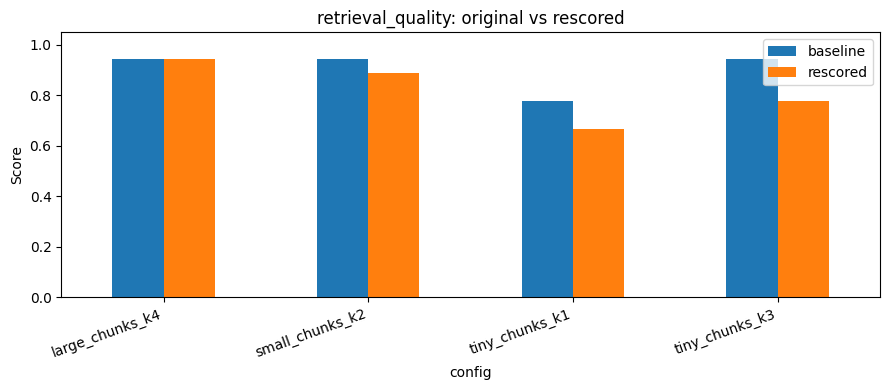

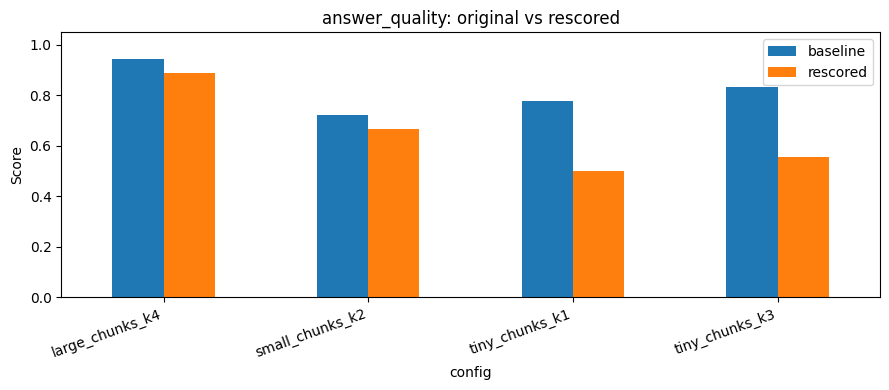

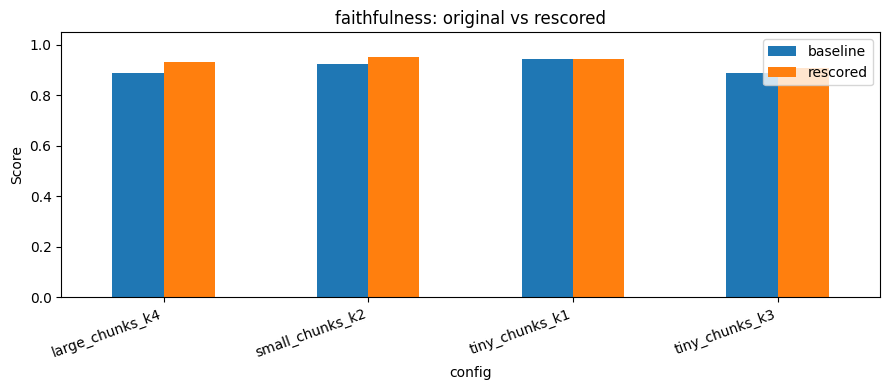

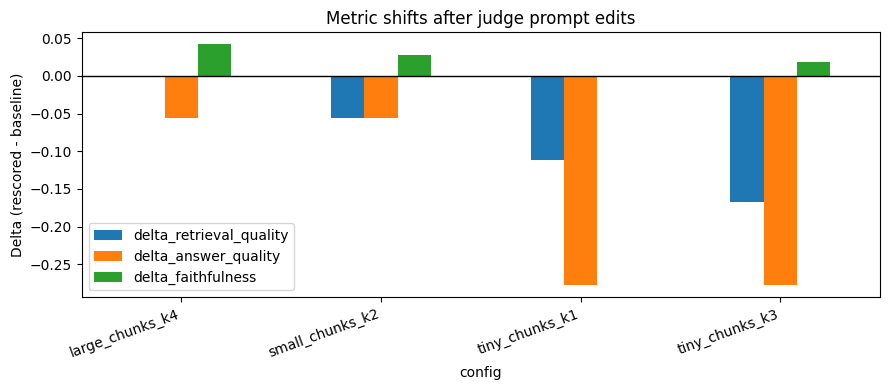

,config,chunk_size,k,retrieval_quality_baseline,answer_quality_baseline,faithfulness_baseline,retrieval_quality_rescored,answer_quality_rescored,faithfulness_rescored
0,large_chunks_k4,80,4,0.944444,0.944444,0.888889,0.944444,0.888889,0.930556
1,small_chunks_k2,12,2,0.944444,0.722222,0.925926,0.888889,0.666667,0.953704
2,tiny_chunks_k1,10,1,0.777778,0.777778,0.944444,0.666667,0.500000,0.944444
3,tiny_chunks_k3,10,3,0.944444,0.833333,0.888889,0.777778,0.555556,0.907407


,config,delta_retrieval_quality,delta_answer_quality,delta_faithfulness
0,large_chunks_k4,0.000000,-0.055556,0.041667
1,small_chunks_k2,-0.055556,-0.055556,0.027778
2,tiny_chunks_k1,-0.111111,-0.277778,0.000000
3,tiny_chunks_k3,-0.166667,-0.277778,0.018519


In [42]:
# Plot baseline vs rescored metrics by config
# Assumes these already exist from prior cells:
# - baseline_metrics (from original judge prompt)
# - edited_metrics   (from rescore_with_current_judge)
# If baseline_metrics is missing, we rebuild it from metrics_by_config.

import matplotlib.pyplot as plt
import pandas as pd

metric_cols = ["retrieval_quality", "answer_quality", "faithfulness"]

if "baseline_metrics" not in globals():
    baseline_metrics = metrics_by_config.copy()

# Build comparison table
cmp_df = baseline_metrics.merge(
    edited_metrics,
    on=["config", "chunk_size", "k"],
    suffixes=("_baseline", "_rescored"),
)

# Keep stable ordering
cmp_df = cmp_df.sort_values(["config"]).reset_index(drop=True)

# 1) Side-by-side bars for each metric
for m in metric_cols:
    plot_df = cmp_df[["config", f"{m}_baseline", f"{m}_rescored"]].set_index("config")
    ax = plot_df.plot(kind="bar", figsize=(9, 4))
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    ax.set_title(f"{m}: original vs rescored")
    ax.legend(["baseline", "rescored"])
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

# 2) Delta plot (rescored - baseline)
delta_df = cmp_df[["config"]].copy()
for m in metric_cols:
    delta_df[f"delta_{m}"] = cmp_df[f"{m}_rescored"] - cmp_df[f"{m}_baseline"]

ax = delta_df.set_index("config").plot(kind="bar", figsize=(9, 4))
ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("Delta (rescored - baseline)")
ax.set_title("Metric shifts after judge prompt edits")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

display(cmp_df)
display(delta_df)

# Part 6 - Compare RAG specs and explain trade-offs
Answer the following in 3-6 sentences each:

1. Which config is best on each metric individually?
2. Is there one config that is best overall? Why or why not?
3. How did increasing `k` affect retrieval quality vs faithfulness?
4. How did chunk size affect answer quality?
5. If you were shipping this system, which config would you choose and what additional metric would you track?


---

--TODO

## Results
Summarize:
- baseline metrics by config,
- how your edited judge prompt changed scores,
- key failure patterns from per-example rationales.

Write here:


## Conclusion
- Was your hypothesis supported?
- What did you learn about LLM-as-judge reliability?
- Which metric seemed most stable across prompt edits?
- What would you monitor in production for RAG quality?

Write here:


---

## 🧠 AI Usage Log

> Use this section to document any generative AI assistance (e.g., ChatGPT, Claude, Copilot) you used while completing this lab or assignment.  
> Be specific — transparency and reflection matter more than the amount of AI use.


| Tool Used | Purpose | Prompt / Context | Verification & Edits |
|------------|----------|------------------|----------------------|
| (e.g., ChatGPT (GPT-5)) | (e.g., debugging, code explanation, idea generation) | (e.g., "Why does my cosine similarity return NaN?") | (e.g., ran tests on sample input, compared with lecture code) |
| (Add rows as needed) | | | |

**Summary (2–3 sentences):**  
Briefly describe what you learned or how AI helped you think through the problem.  
Example: *AI helped me notice an off-by-one error in my indexing. I double-checked by printing intermediate results and confirmed the fix.*

---



In [ ]:
# @title ✅ Checks for RAG evaluation lab
print("Running checks...")

required_metric_cols = {"retrieval_quality", "answer_quality", "faithfulness"}

try:
    assert len(corpus_docs) >= 4
    assert len(eval_df) >= 4
    print("✅ Dataset objects exist.")
except Exception as e:
    print("❌ Dataset check failed:", e)

try:
    test_chunks = build_chunk_index(corpus_docs, chunk_size=40, overlap=10)
    r = retrieve("remote work", test_chunks, k=2)
    assert len(r) == 2
    print("✅ Retrieval pipeline works.")
except Exception as e:
    print("❌ Retrieval pipeline check failed:", e)

try:
    assert required_metric_cols.issubset(set(results_df.columns))
    assert results_df["retrieval_quality"].map(lambda x: isinstance(x, (bool, np.bool_))).all()
    assert results_df["answer_quality"].map(lambda x: isinstance(x, (bool, np.bool_))).all()
    assert ((results_df["faithfulness"] >= 0.0) & (results_df["faithfulness"] <= 1.0)).all()
    assert (results_df["supported_count"] <= results_df["answer_assertion_count"]).all()
    print("✅ Judge metrics present with assertion-level faithfulness.")
except Exception as e:
    print("❌ Judge metric check failed:", e)

try:
    assert required_metric_cols.issubset(set(metrics_by_config.columns))
    print("✅ Aggregation table looks correct.")
except Exception as e:
    print("❌ Aggregation check failed:", e)

print("Done.")
